In [1]:
import pydeseq2
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

import scanpy as sc
import scanpy.external as sce
from scipy.sparse import csr_matrix
import harmonypy as hm
import sklearn
import numpy as np
import pandas as pd
import statsmodels as stat
import matplotlib.pyplot as plt
import seaborn as sns
import anndata as ad
import gseapy as gp
import os
import tarfile
import glob
import GEOparse
import urllib.request
import io

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)

Research Question: \
"Are the bulk DEGs identified in JMML (GSE147523) driven by true cell-intrinsic dysregulation within hematopoietic stem/progenitor cells, or are they artifacts reflecting shifts in progenitor cell-type proportions?"

In [2]:
# Configure Scanpy settings, enabling Parallel Processing

sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=120, facecolor="white", frameon=True, figsize=(6, 5))
os.environ["OMP_NUM_THREADS"] = "4"
sc.settings.n_jobs = 4

In [3]:
# Loading data

adata = sc.read_h5ad("../Data/GSE111893/GSE111893_raw.h5ad")

## Scanpy standard workflow:

### QC and Filtering

In [4]:
adata.var['mt'] = adata.var_names.str.startswith('MT-')
adata.var['ribo'] = adata.var_names.str.startswith(('RPS', 'RPL'))

In [5]:
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt', 'ribo'], percent_top=None, log1p=False, inplace=True)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [6]:
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

filtered out 10339 genes that are detected in less than 3 cells


In [7]:
adata = adata[adata.obs['pct_counts_mt'] < 15, :].copy()

In [8]:
adata

AnnData object with n_obs × n_vars = 17547 × 22399
    obs: 'condition', 'sample_id', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'n_genes'
    var: 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'

## Normalization and Feature Selection

In [9]:
adata.layers['counts'] = adata.X.copy()

In [10]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

normalizing counts per cell
    finished (0:00:00)


In [11]:
adata.raw = adata

In [12]:
sc.pp.highly_variable_genes(
    adata, 
    n_top_genes=3000, 
    subset=False, 
    layer='counts', 
    flavor='seurat_v3'
)

extracting highly variable genes


/Users/alexchen/anaconda3/envs/jmml_transcriptomics/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  return fn(*args_all, **kw)


--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'variances_norm', float vector (adata.var)


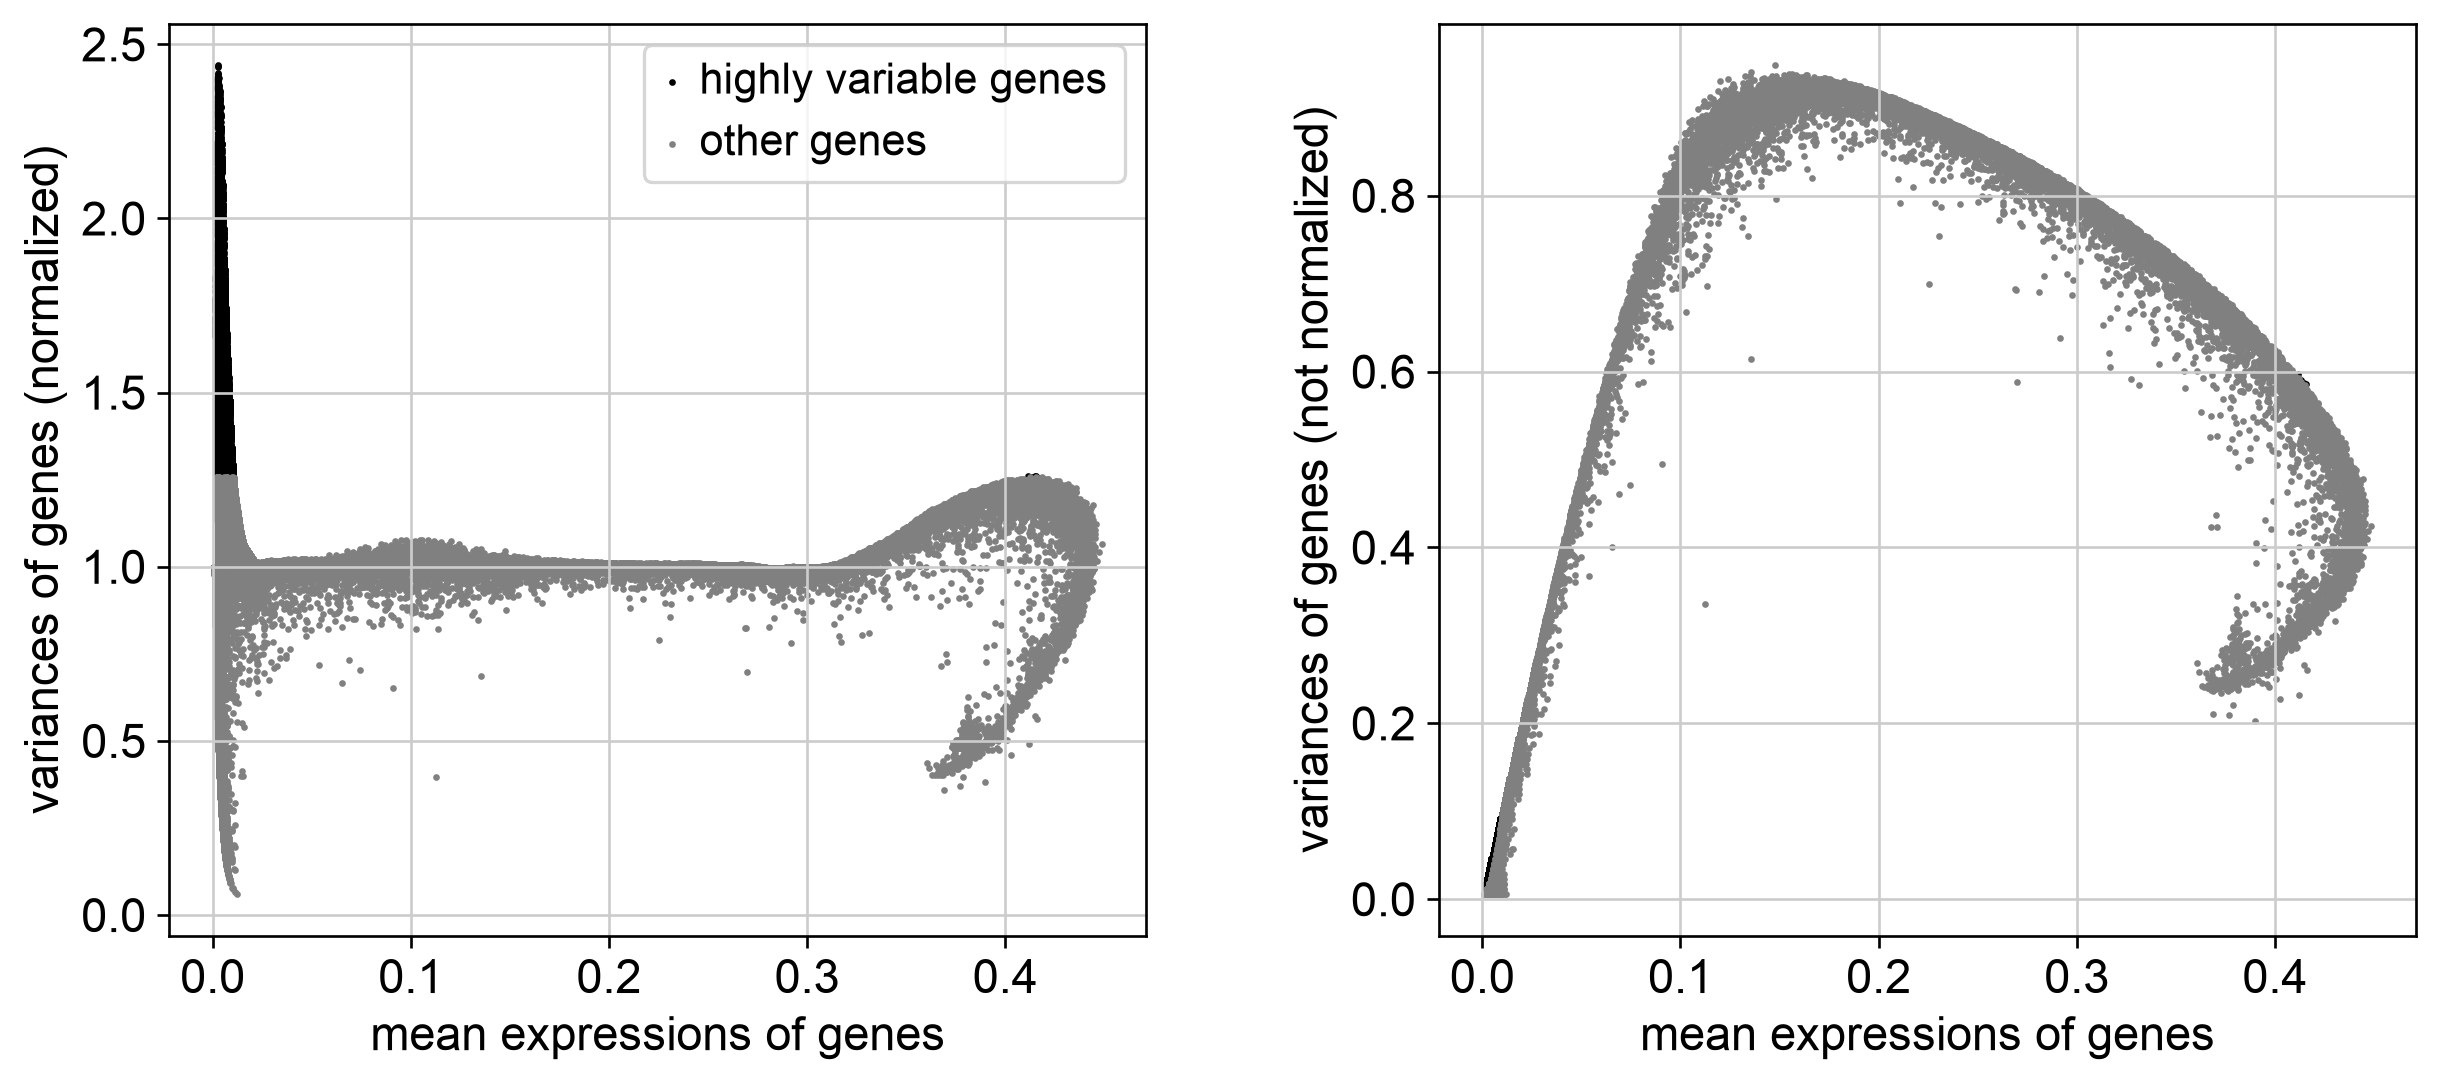

In [13]:
sc.pl.highly_variable_genes(adata)

In [14]:
adata

AnnData object with n_obs × n_vars = 17547 × 22399
    obs: 'condition', 'sample_id', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'n_genes'
    var: 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'log1p', 'hvg'
    layers: 'counts'

## Dimensionality Reduction and Clustering

In [15]:
sc.tl.pca(adata, svd_solver='arpack', use_highly_variable=True)

computing PCA
    with n_comps=50
    finished (0:00:10)


In [16]:
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=30)
sc.tl.umap(adata)

computing neighbors
    using 'X_pca' with n_pcs = 30


/Users/alexchen/anaconda3/envs/jmml_transcriptomics/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:58)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:12)


In [17]:
sc.tl.leiden(adata, resolution=0.5, key_added='leiden_0.5')

running Leiden clustering
    finished: found 22 clusters and added
    'leiden_0.5', the cluster labels (adata.obs, categorical) (0:00:22)


## Cell Type Annotation

In [18]:
sc.tl.rank_genes_groups(adata, groupby='leiden_0.5', method='wilcoxon')

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:21)


In [19]:
result_df = sc.get.rank_genes_groups_df(adata, group=None)

In [20]:
result_df.head(10)

,group,names,scores,logfoldchanges,pvals,pvals_adj
0,0,AC073842.19,19.521503,0.915926,7.208665e-85,2.311138e-81
1,0,RP11-461F11.3,19.514360,1.013484,8.290046e-85,2.311138e-81
2,0,RP11-136K7.1,19.509769,0.880161,9.068974e-85,2.311138e-81
3,0,FAM86B2,19.506956,0.858486,9.582020e-85,2.311138e-81
4,0,RP1-46F2.3,19.497030,0.744601,1.163427e-84,2.311138e-81
5,0,EFCAB1,19.488495,0.723853,1.374660e-84,2.311138e-81
6,0,RP11-354I13.2,19.488426,0.754443,1.376514e-84,2.311138e-81
7,0,NEDD8-MDP1,19.483635,0.754132,1.511556e-84,2.311138e-81
8,0,RP11-38G5.4,19.483635,0.754132,1.511556e-84,2.311138e-81
9,0,RP11-570L15.1,19.480803,0.740064,1.597573e-84,2.311138e-81


In [21]:
# Top Markers of cluster 0 (Upregulated)
top_markers_cluster0 = result_df[
    (result_df['group'] == '0') & 
    (result_df['logfoldchanges'] > 1.0) & 
    (result_df['pvals_adj'] < 0.05)
]

top_markers_cluster0.head(10)

,group,names,scores,logfoldchanges,pvals,pvals_adj
1,0,RP11-461F11.3,19.514360,1.013484,8.290046e-85,2.311138e-81
21,0,CBLN2,19.416208,1.204507,5.629566e-84,4.849871e-81
56,0,ILDR1,18.438053,1.059484,6.504233e-76,2.388333e-73
71,0,CTD-3025N20.2,17.888777,1.195549,1.442394e-71,4.251078e-69
90,0,LRRN3,16.912701,1.227328,3.626984e-64,8.551665e-62
100,0,AL136115.1,16.367815,1.087731,3.246653e-60,6.925883e-58
129,0,CTD-2568A17.5,15.300865,1.018228,7.544679e-53,1.261144e-50
130,0,FRMD5,15.096718,1.003283,1.701979e-51,2.823898e-49
134,0,OR1N2,15.023227,1.241791,5.172742e-51,8.335557e-49
139,0,VN1R2,14.778042,1.118386,2.029817e-49,3.157352e-47


In [22]:
# Filtering out noise (Non-protein coding) genes
filtered_markers = result_df[
    (result_df['pvals_adj'] < 0.05) & 
    (result_df['logfoldchanges'] > 0.5) &
    (~result_df['names'].str.startswith(('RP11-', 'AC0', 'RP1-', 'MT-', 'RPS', 'RPL')))
]

In [23]:
top_markers_per_cluster = filtered_markers.groupby('group').head(5)
top_markers_per_cluster

,group,names,scores,logfoldchanges,pvals,pvals_adj
3,0,FAM86B2,19.506956,0.858486,9.582020e-85,2.311138e-81
5,0,EFCAB1,19.488495,0.723853,1.374660e-84,2.311138e-81
7,0,NEDD8-MDP1,19.483635,0.754132,1.511556e-84,2.311138e-81
10,0,LINC00242,19.477171,0.752506,1.714952e-84,2.311138e-81
11,0,GAB4,19.474190,0.732415,1.817785e-84,2.311138e-81
...,...,...,...,...,...,...
470381,21,LCA10,9.899786,4.048542,4.171671e-23,2.392080e-21
470382,21,CPEB1,9.899549,3.919058,4.181577e-23,2.392080e-21
470383,21,LINC00434,9.899515,3.880549,4.182994e-23,2.392080e-21
470385,21,TAGLN3,9.898566,3.798033,4.222868e-23,2.392080e-21


    using 'X_pca' with n_pcs = 50
Storing dendrogram info using `.uns['dendrogram_leiden_0.5']`


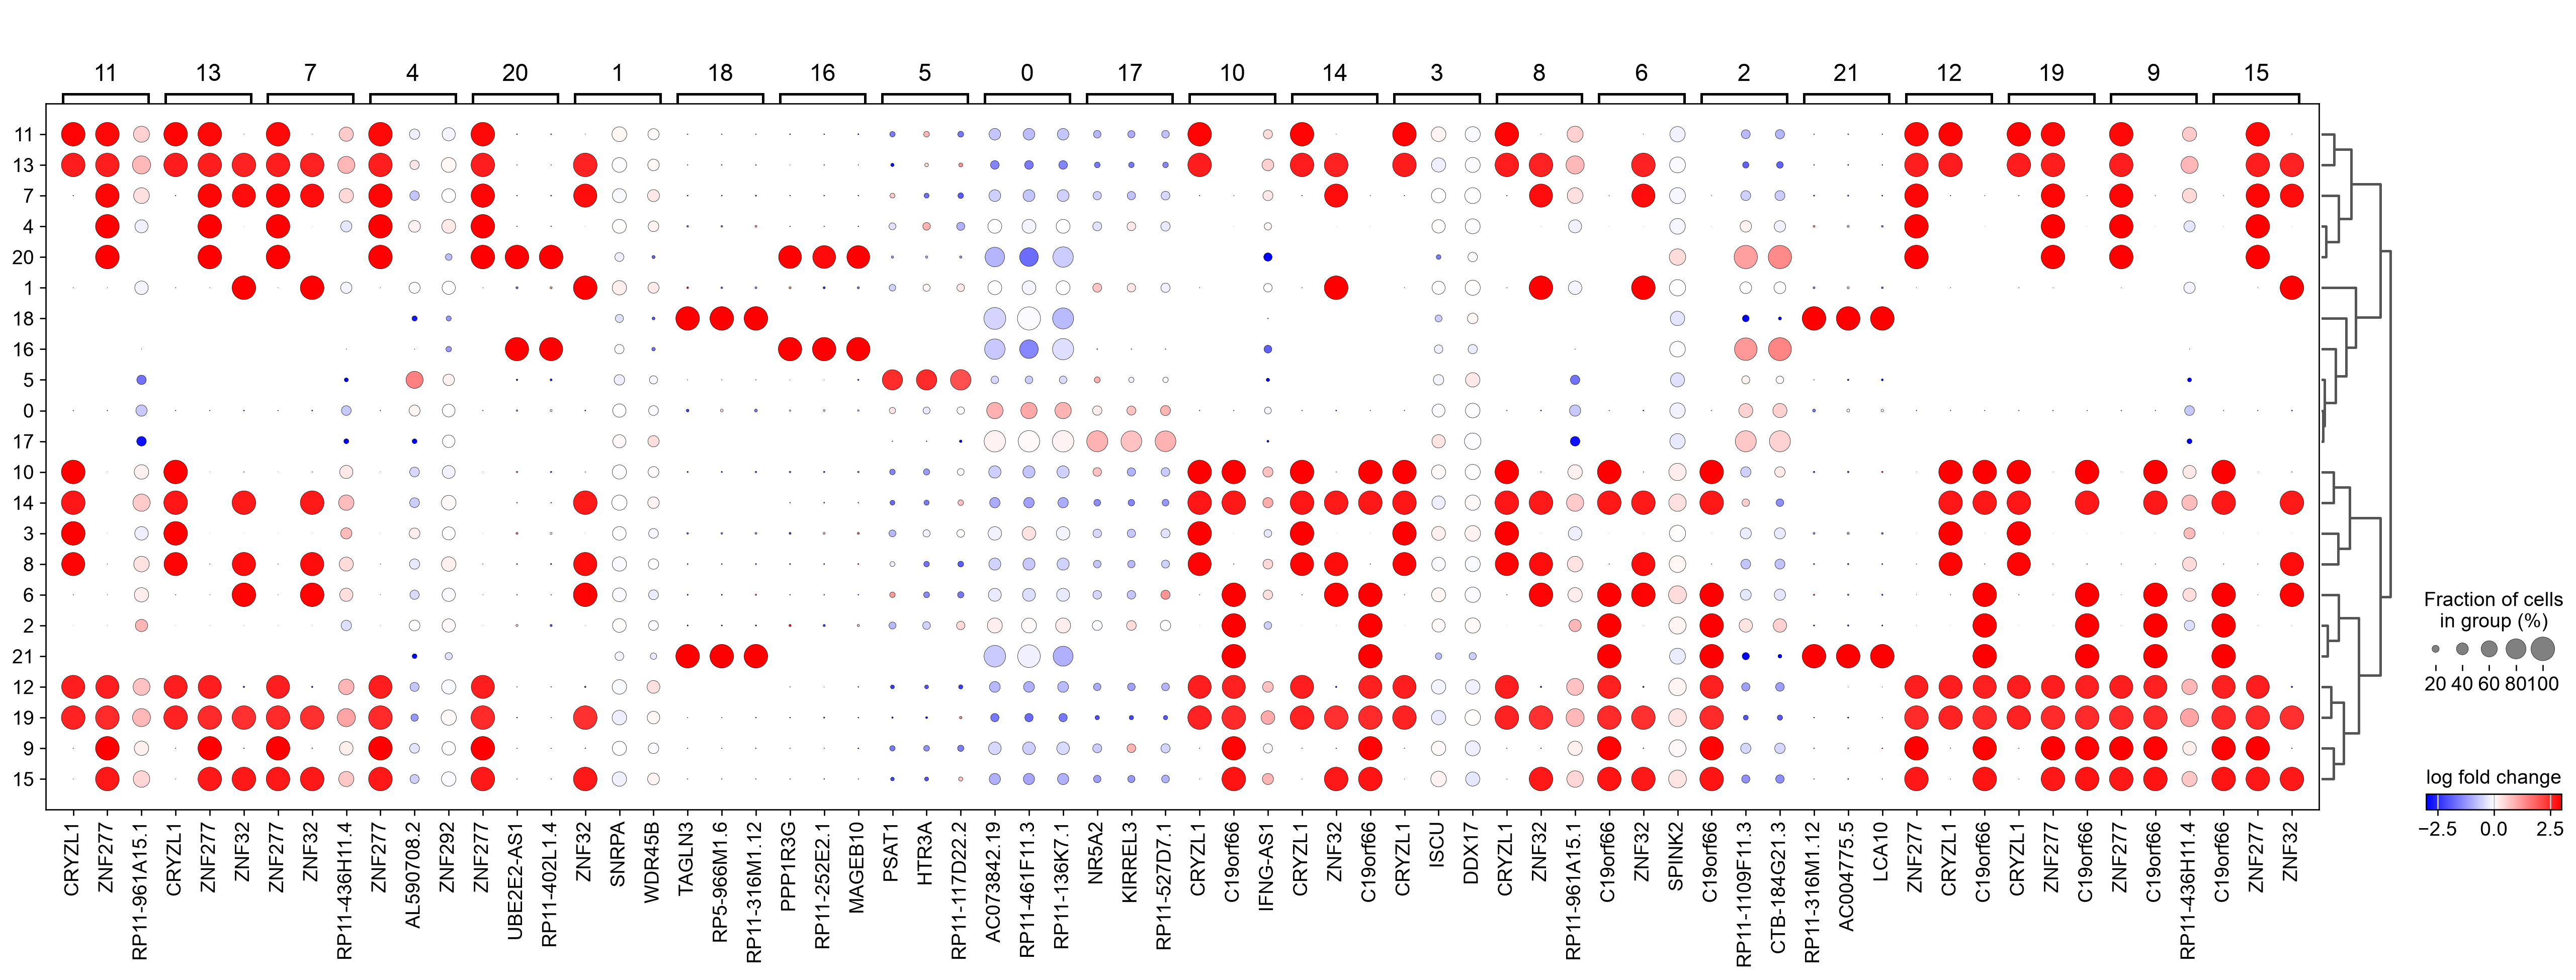

In [24]:
# Dotplotting
sc.pl.rank_genes_groups_dotplot(
    adata, 
    n_genes=3, 
    values_to_plot='logfoldchanges', 
    vmax=3, 
    vmin=-3, 
    cmap='bwr'
)

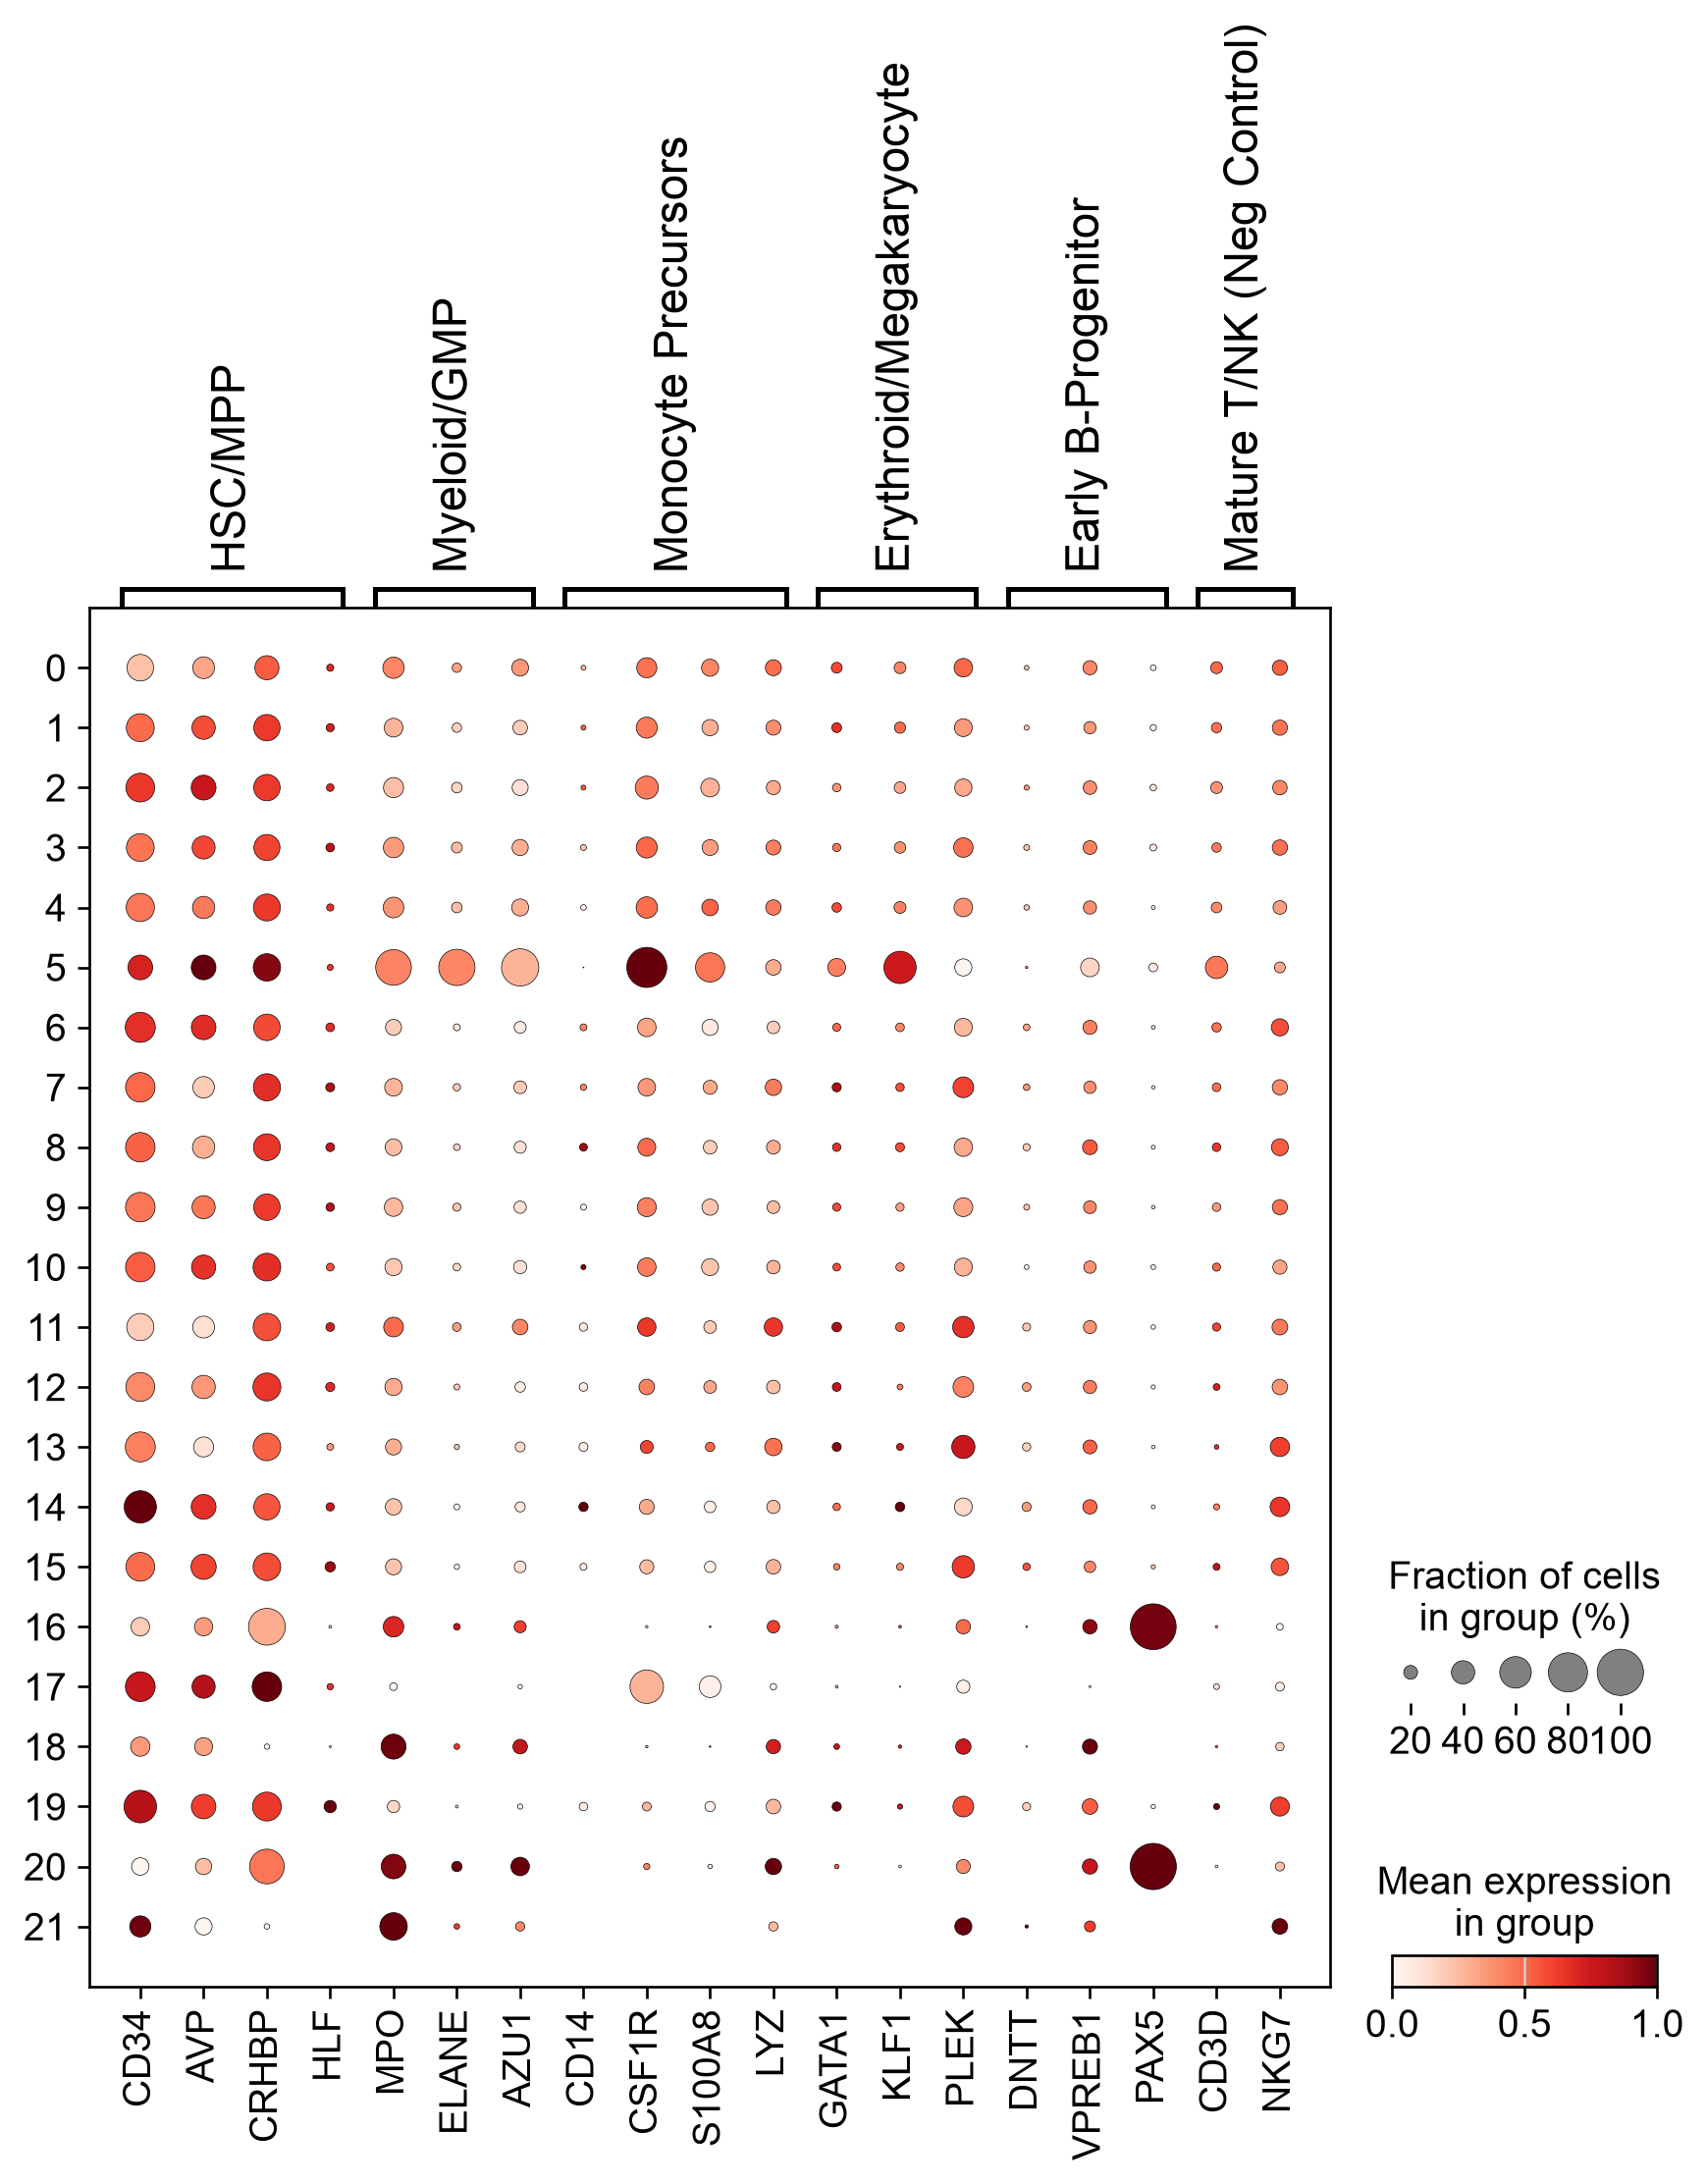

In [25]:
# Expanded panel: Progenitors + Myelomonocytic + Early Lymphoid + Negative Controls
canonical_panel = {
    'HSC/MPP': ['CD34', 'AVP', 'CRHBP', 'HLF'],
    'Myeloid/GMP': ['MPO', 'ELANE', 'AZU1'],
    'Monocyte Precursors': ['CD14', 'CSF1R', 'S100A8', 'LYZ'],
    'Erythroid/Megakaryocyte': ['GATA1', 'KLF1', 'PLEK'],
    'Early B-Progenitor': ['DNTT', 'VPREB1', 'PAX5'],
    'Mature T/NK (Neg Control)': ['CD3D', 'NKG7']
}
sc.pl.dotplot(adata, canonical_panel, groupby='leiden_0.5', standard_scale='var')

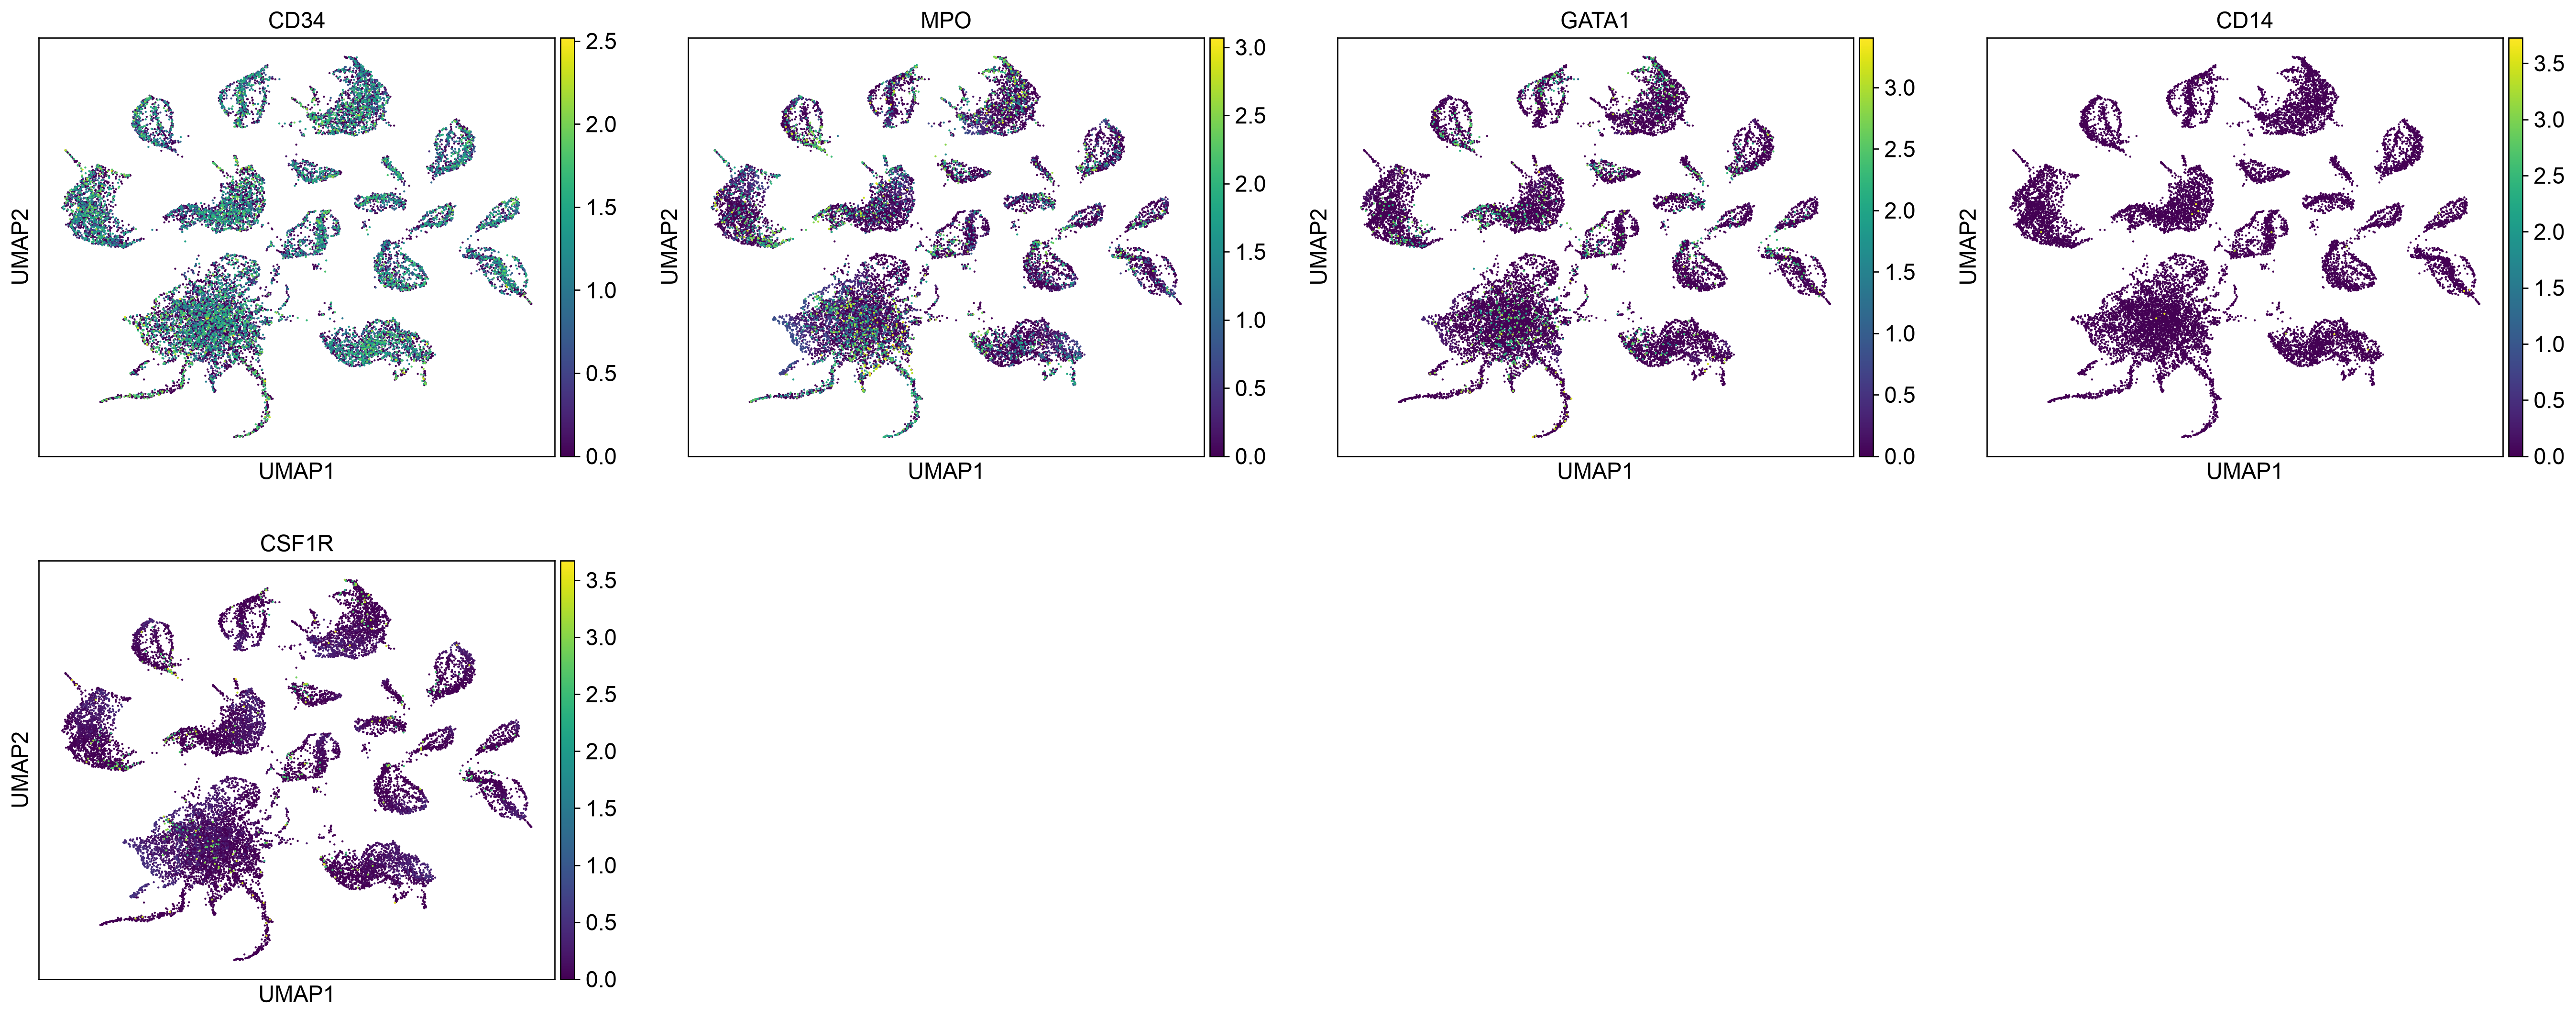

In [26]:
# Checking for HSC/MPP, GMP/Myeloblast, CMP/MEP, Monocyte Precursors
lineage_markers = ['CD34', 'MPO', 'GATA1', 'CD14', 'CSF1R']
valid_markers = [m for m in lineage_markers if m in adata.var_names]
sc.pl.umap(adata, color=valid_markers, color_map='viridis')